# Costs Modeling

In this notebook we are going to set the data to train our **Linear Regression Model** and predict the costs from future features.


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Training and Testing Data

We will call some functions and the Linear Regression Model from `SciKit-Learn`.

In [2]:
from sklearn.model_selection import train_test_split

From the previous notebook, lets recall the features and target DataFrames. 

In [18]:
X = pd.read_csv('../data/feature_data.csv')
X.shape

(15000, 23)

In [20]:
y = pd.read_csv('../data/target_data.csv')
y.shape

(15000, 1)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

## Training the Model

Lets import the model and train it.

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
lm = LinearRegression()

In [24]:
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 23)","[[ 0. ,-0. , 0. ,..., 0.01,-0.01, 0.01]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](23,)","['spindle_speed','motor_current','vibration',...,'product_type_Product_B', 'product_type_Product_C','product_type_Product_D']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[5.49]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,23
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,21


In [25]:
print(lm.coef_)

[[ 1.19843831e-06 -1.73780155e-04  1.13699475e-03 -1.91359304e-03
   4.99353932e-04 -8.77509060e-04  1.56229661e-01  1.05150380e-02
   2.90018242e-02 -4.46811036e-03 -6.11145754e-03  1.70577624e-02
   1.87413094e-03  9.29356452e-04 -1.41017157e-02 -2.08296257e-02
  -1.84540856e-04  3.02188077e-03 -2.83733991e-03 -1.10911471e-02
   1.13335533e-02 -6.79831170e-03  6.55590546e-03]]


In [26]:
predictions = lm.predict(X_test)

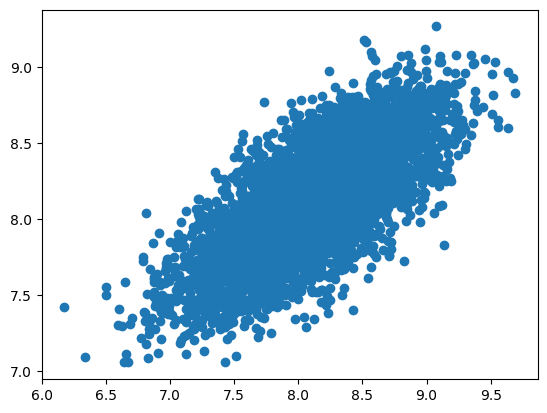

In [27]:
plt.scatter(y_test, predictions)

In [31]:
from sklearn import metrics
mean_abs_error = metrics.mean_absolute_error(y_test, predictions)
mean_sqr_error = metrics.mean_squared_error(y_test, predictions)
root_mean_sqr_error = metrics.root_mean_squared_error(y_test, predictions)


print(mean_abs_error)
print(mean_sqr_error)
print(root_mean_sqr_error)

0.2758992262242944
0.11941623267694745
0.3455665387113565


<Axes: ylabel='Count'>

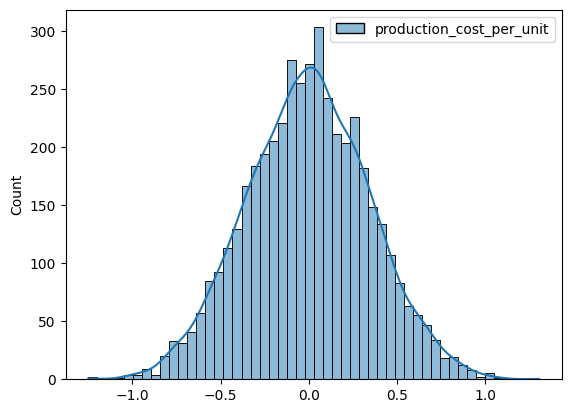

In [34]:
sns.histplot(kde=True, data=(y_test-predictions), bins=50)

In [37]:
X.columns

Index(['spindle_speed', 'motor_current', 'vibration', 'flow_rate',
       'production_volume', 'power_consumption', 'energy_per_unit',
       'fault_event_count', 'downtime_minutes', 'maintenance_frequency',
       'resource_efficiency', 'production_efficiency', 'energy_saving_pct',
       'downtime_reduction_pct', 'cost_reduction_pct', 'benefit_score',
       'shift_Afternoon', 'shift_Morning', 'shift_Night',
       'product_type_Product_A', 'product_type_Product_B',
       'product_type_Product_C', 'product_type_Product_D'],
      dtype='str')

In [36]:
coefficient = pd.DataFrame(lm.coef_, X.columns)
#coefficient.columns = ['Coefficient']
coefficient 

ValueError: Shape of passed values is (1, 23), indices imply (23, 23)